# LAB 03 : Regression & Classification

Dataset: `age_gender.csv`

## 1. Import library


In [36]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score,
    classification_report
)

# โหลดข้อมูลตรงจาก age_gender.csv
meta = pd.read_csv("age_gender.csv")
pixels = np.array([np.fromstring(x, sep=' ') for x in meta['pixels']])

# Helper Functions
def to_features(p): return p / 255.0
def as_images(p, width=48, height=48): return p.reshape(-1, width, height)

X = to_features(pixels)

# LAB 1 : Regression


## 1.Simple Linear Regression


In [37]:
# ใช้ค่าเฉลี่ย Pixel เป็น 1 Feature
X_simple = X.mean(axis=1).reshape(-1, 1)
y_age = meta["age"].to_numpy()

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y_age, test_size=0.2, random_state=42
)

model_simple = LinearRegression()
model_simple.fit(X_train_s, y_train_s)
pred_simple = model_simple.predict(X_test_s).clip(1, 116)

print("Simple Linear Regression Result:")
print("MAE :", mean_absolute_error(y_test_s, pred_simple))
print("MSE :", mean_squared_error(y_test_s, pred_simple))
print("R2  :", r2_score(y_test_s, pred_simple))

Simple Linear Regression Result:
MAE : 15.211038673800445
MSE : 382.61482596788085
R2  : 0.010047397198665542


## 2.Multiple Linear Regression

In [38]:
# ใช้ Pipeline (StandardScaler + PCA + Ridge Regression)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X, y_age, test_size=0.2, random_state=42
)

model_multiple = make_pipeline(
    StandardScaler(),
    PCA(n_components=150, random_state=42),
    Ridge(alpha=1.0)
)

model_multiple.fit(X_train_m, y_train_m)
pred_multiple = model_multiple.predict(X_test_m).clip(1, 116)

print("Multiple Linear Regression Result:")
print("MAE :", mean_absolute_error(y_test_m, pred_multiple))
print("MSE :", mean_squared_error(y_test_m, pred_multiple))
print("R2  :", r2_score(y_test_m, pred_multiple))

Multiple Linear Regression Result:
MAE : 11.048697008820477
MSE : 208.090615312894
R2  : 0.4615999374137594


## 3.Age Prediction


   Actual age  Predicted age
0          49           26.5
1          39           43.6
2           8           13.4
3          40           26.2
4          27           23.0
5          54           41.4
6          36           30.2
7          54           44.0
8          35           42.9
9          62           54.6


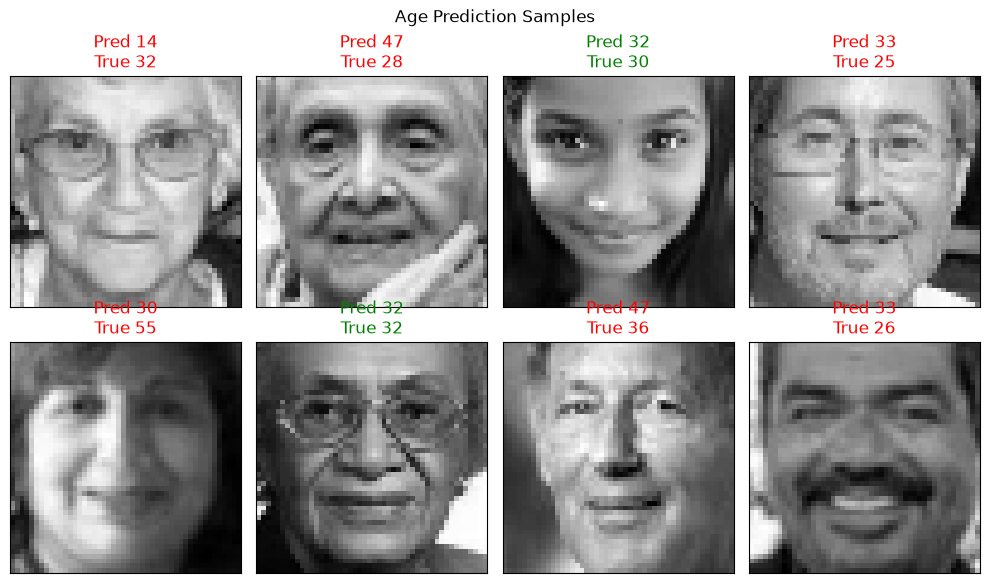

In [39]:
age_result = pd.DataFrame({
    "Actual age": y_test_m[:10],
    "Predicted age": np.round(pred_multiple[:10], 1)
})
print(age_result)

# พล็อตตัวอย่าง 8 รูป (สีเขียว = คลาดเคลื่อนไม่เกิน 5 ปี)
np.random.seed(42)
sample_idx = np.random.choice(len(X_test_m), 8, replace=False)
fig, axes = plt.subplots(2, 4, figsize=(10, 6))
test_imgs = as_images(pixels[len(X_train_m):])

for ax, i in zip(axes.ravel(), sample_idx):
    correct = abs(pred_multiple[i] - y_test_m[i]) <= 5
    ax.imshow(test_imgs[i], cmap="gray")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"Pred {pred_multiple[i]:.0f}\nTrue {y_test_m[i]}", color="green" if correct else "red")

fig.suptitle("Age Prediction Samples")
plt.tight_layout()
plt.show()

# LAB 2 : Classification


## 4.Preparing Classification Data

In [40]:
y_gender = meta["gender"].to_numpy()
CLASSES = ["Male", "Female"]

X_train_c, X_test_c, y_train_c, y_test_c, _, test_idx_c = train_test_split(
    X, y_gender, np.arange(len(X)), test_size=0.2, random_state=42, stratify=y_gender
)

print(f"Train samples: {len(X_train_c)} | Test samples: {len(X_test_c)}")

Train samples: 18964 | Test samples: 4741


## 5.Decision Boundary Visualization

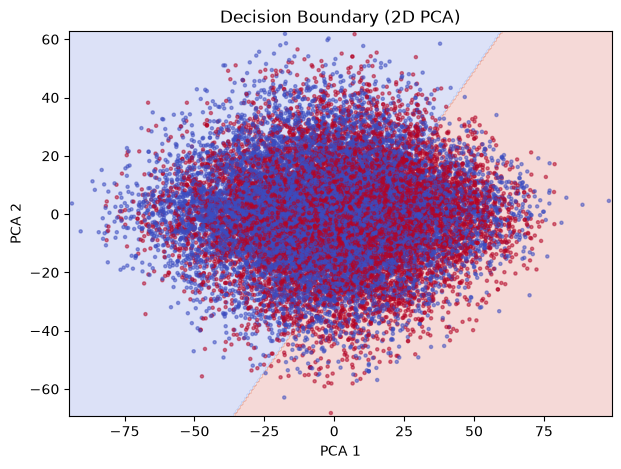

In [41]:
pca_2 = PCA(n_components=2)
X_2d = pca_2.fit_transform(StandardScaler().fit_transform(X))

clf_2d = LogisticRegression(max_iter=500)
clf_2d.fit(X_2d, y_gender)

x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
zz = clf_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, zz, alpha=0.2, cmap="coolwarm")
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_gender, s=5, cmap="coolwarm", alpha=0.5)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Decision Boundary (2D PCA)")
plt.show()

## 6.Logistic Regression

In [42]:
# ใช้ Pipeline (StandardScaler + PCA + LogisticRegression)
model_gender = make_pipeline(
    StandardScaler(),
    PCA(n_components=100, random_state=42),
    LogisticRegression(C=1.0, max_iter=1000)
)

model_gender.fit(X_train_c, y_train_c)
pred_gender = model_gender.predict(X_test_c)
prob_gender = model_gender.predict_proba(X_test_c)[:, 1]

print("Accuracy :", accuracy_score(y_test_c, pred_gender))
print("Precision:", precision_score(y_test_c, pred_gender))
print("Recall   :", recall_score(y_test_c, pred_gender))
print("F1-score :", f1_score(y_test_c, pred_gender))

Accuracy : 0.8375870069605569
Precision: 0.833407771326485
Recall   : 0.824569155987627
F1-score : 0.8289649044868947


## 7.Gender Prediction


  Actual gender Predicted gender
0          Male             Male
1          Male             Male
2          Male             Male
3        Female           Female
4        Female           Female
5        Female           Female
6        Female           Female
7          Male             Male
8        Female           Female
9          Male             Male


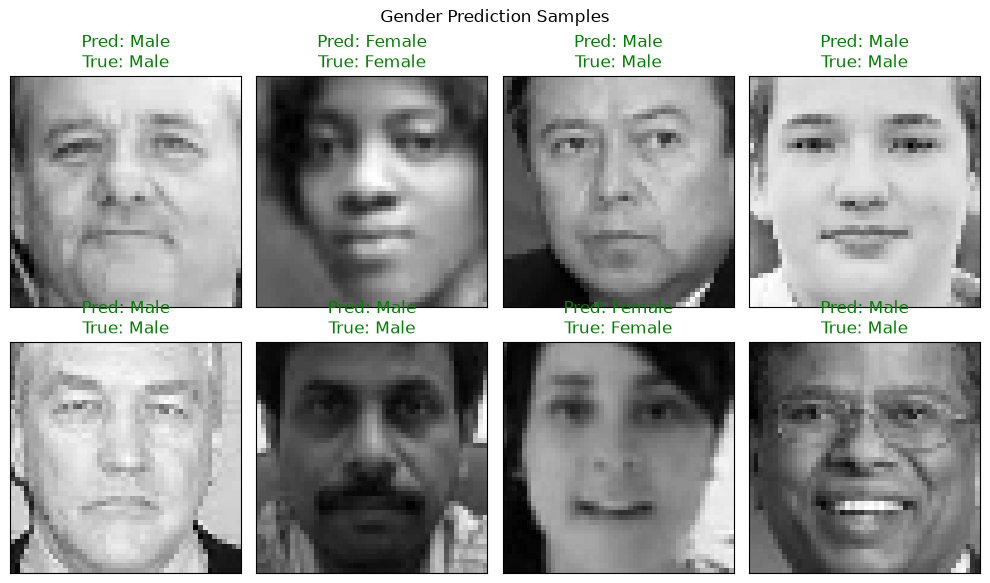

In [43]:
gender_result = pd.DataFrame({
    "Actual gender": [CLASSES[val] for val in y_test_c[:10]],
    "Predicted gender": [CLASSES[val] for val in pred_gender[:10]]
})
print(gender_result)

# พล็อตตัวอย่าง 8 รูป (สีเขียว = ทายเพศถูก)
np.random.seed(42)
sample_idx_c = np.random.choice(len(X_test_c), 8, replace=False)
fig, axes = plt.subplots(2, 4, figsize=(10, 6))
test_imgs_c = as_images(pixels[test_idx_c])

for ax, i in zip(axes.ravel(), sample_idx_c):
    correct = pred_gender[i] == y_test_c[i]
    ax.imshow(test_imgs_c[i], cmap="gray")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"Pred: {CLASSES[pred_gender[i]]}\nTrue: {CLASSES[y_test_c[i]]}", color="green" if correct else "red")

fig.suptitle("Gender Prediction Samples")
plt.tight_layout()
plt.show()

## 8.Confusion Matrix

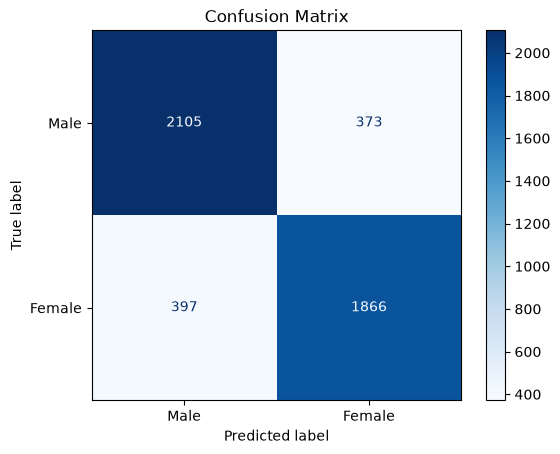

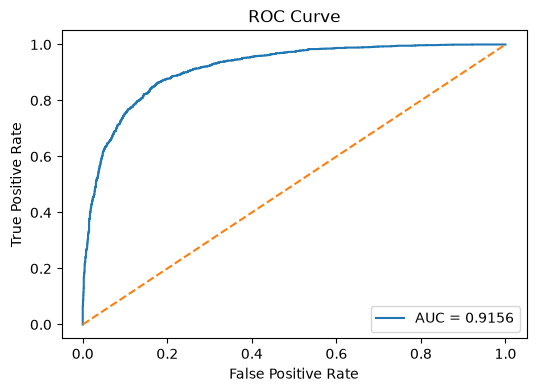

In [44]:
cm = confusion_matrix(y_test_c, pred_gender)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# ROC Curve & AUC
fpr, tpr, _ = roc_curve(y_test_c, prob_gender)
auc_score = roc_auc_score(y_test_c, prob_gender)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# LAB 3 : Model Comparison


## 9.Simple vs Multiple Linear Regression

In [45]:
comp_df = pd.DataFrame({
    "Model": ["Simple Linear Regression", "Multiple Linear Regression"],
    "MAE": [mean_absolute_error(y_test_s, pred_simple), mean_absolute_error(y_test_m, pred_multiple)],
    "MSE": [mean_squared_error(y_test_s, pred_simple), mean_squared_error(y_test_m, pred_multiple)],
    "R2 Score": [r2_score(y_test_s, pred_simple), r2_score(y_test_m, pred_multiple)]
})
print(comp_df)

                        Model        MAE         MSE  R2 Score
0    Simple Linear Regression  15.211039  382.614826  0.010047
1  Multiple Linear Regression  11.048697  208.090615  0.461600


## 10.Training vs Testing Performance

In [46]:
pred_simple_train = model_simple.predict(X_train_s).clip(1, 116)
pred_multiple_train = model_multiple.predict(X_train_m).clip(1, 116)

overfit_df = pd.DataFrame({
    "Model": ["Simple Linear Regression", "Multiple Linear Regression"],
    "Train R2": [r2_score(y_train_s, pred_simple_train), r2_score(y_train_m, pred_multiple_train)],
    "Test R2": [r2_score(y_test_s, pred_simple), r2_score(y_test_m, pred_multiple)]
})
print(overfit_df)

                        Model  Train R2   Test R2
0    Simple Linear Regression  0.019286  0.010047
1  Multiple Linear Regression  0.469507  0.461600


## 11.Regression vs Classification

In [47]:
task_comp = pd.DataFrame({
    "Task": ["Regression", "Classification"],
    "Target": ["Age (Continuous)", "Gender (Categorical)"],
    "Algorithm": ["Ridge Regression", "Logistic Regression"],
    "Main Metric": [f"R2 = {r2_score(y_test_m, pred_multiple):.3f}", f"Accuracy = {accuracy_score(y_test_c, pred_gender):.3f}"]
})
print(task_comp)

             Task                Target            Algorithm       Main Metric
0      Regression      Age (Continuous)     Ridge Regression        R2 = 0.462
1  Classification  Gender (Categorical)  Logistic Regression  Accuracy = 0.838


## 12.Model Performance Metrics

In [48]:
print("--- Classification Performance Report ---")
print(classification_report(y_test_c, pred_gender, target_names=CLASSES))

print("--- Regression Metrics ---")
print(f"MAE  : {mean_absolute_error(y_test_m, pred_multiple):.2f} years")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test_m, pred_multiple)):.2f} years")
print(f"R2   : {r2_score(y_test_m, pred_multiple):.4f}")

--- Classification Performance Report ---
              precision    recall  f1-score   support

        Male       0.84      0.85      0.85      2478
      Female       0.83      0.82      0.83      2263

    accuracy                           0.84      4741
   macro avg       0.84      0.84      0.84      4741
weighted avg       0.84      0.84      0.84      4741

--- Regression Metrics ---
MAE  : 11.05 years
RMSE : 14.43 years
R2   : 0.4616
